In [7]:
import pandas as pd
import numpy as np 


In [8]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(5268)

In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [13]:
df["CustomerID"].nunique()

4372

In [14]:
df["InvoiceNo"].nunique()

25900

In [15]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [16]:
df[df["InvoiceNo"].astype(str).str.startswith("C")].shape

(9288, 8)

In [17]:
clean_df = df.copy()

In [18]:
clean_df = clean_df.drop_duplicates()

In [19]:
clean_df.shape

(536641, 8)

In [20]:
clean_df = clean_df.dropna(subset=["CustomerID"])

In [21]:
clean_df.shape

(401604, 8)

In [22]:
clean_df = clean_df[clean_df["Quantity"] > 0]

In [23]:
clean_df.shape

(392732, 8)

In [24]:
# Check first
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [25]:
clean_df = clean_df[clean_df["UnitPrice"] > 0]

In [26]:
clean_df.shape

(392692, 8)

In [27]:
clean_df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [28]:
clean_df.duplicated().sum()

np.int64(0)

In [29]:
(clean_df["Quantity"] < 0).sum()

np.int64(0)

In [30]:
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

In [32]:
clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [33]:
clean_df.shape

(392692, 9)

In [34]:
clean_df.to_csv(
    "../data/processed/cleaned_data.csv",
    index=False
)

In [35]:
import os

os.path.exists(
    "../data/processed/cleaned_data.csv"
)

True

In [36]:
purchase_freq = (
    clean_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

purchase_freq.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

clean_df = pd.read_csv("../data/processed/cleaned_data.csv")

In [38]:
clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [39]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  str    
 2   Description  392692 non-null  str    
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  str    
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  str    
 8   Revenue      392692 non-null  float64
dtypes: float64(3), int64(2), str(4)
memory usage: 50.9 MB


In [40]:
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])

In [41]:
print("Total Customers :", clean_df["CustomerID"].nunique())

print("Total Transactions :", clean_df["InvoiceNo"].nunique())

print("Total Revenue :", round(clean_df["Revenue"].sum(),2))

Total Customers : 4338
Total Transactions : 18532
Total Revenue : 8887208.89


## Business Overview

- Total Customers: 4,338
- Total Transactions: 18,532
- Total Revenue: 8,887,208.89

The dataset contains over 4,000 customers and 18,000 completed transactions, generating approximately 8.89 million in revenue. This provides sufficient customer history for segmentation, churn prediction, customer lifetime value estimation, and retention analysis.

In [42]:
purchase_freq = (
    clean_df.groupby("CustomerID")
    ["InvoiceNo"]
    .nunique()
)

In [43]:
purchase_freq.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

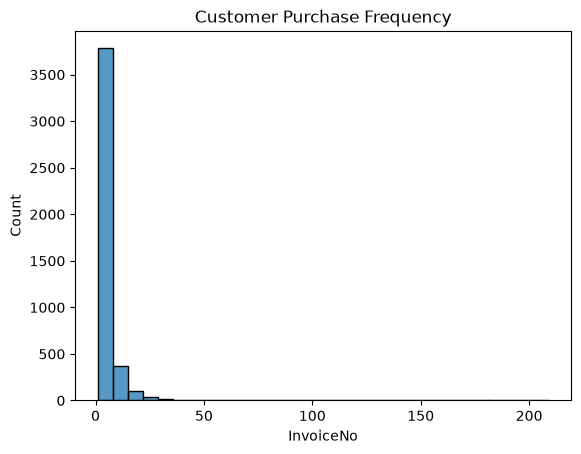

In [44]:
sns.histplot(
    purchase_freq,
    bins=30
)

plt.title("Customer Purchase Frequency")
plt.show()

Customer purchase frequency is highly right-skewed. The median customer places only 2 orders, while 75% of customers place 5 or fewer orders. A small group of highly loyal customers places significantly more orders, with the most active customer placing 209 orders. This suggests strong variation in customer loyalty and highlights Frequency as an important feature for segmentation and churn modeling.

In [45]:
customer_revenue = (
    clean_df.groupby("CustomerID")
    ["Revenue"]
    .sum()
)

In [46]:
customer_revenue.describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Revenue, dtype: float64

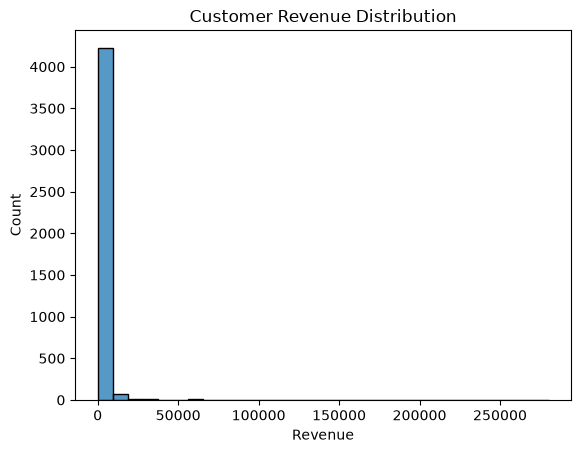

In [47]:
sns.histplot(
    customer_revenue,
    bins=30
)

plt.title("Customer Revenue Distribution")
plt.show()

Observation:

Customer revenue distribution is highly right-skewed. Most customers generate relatively low revenue, while a small group of customers contributes disproportionately high revenue. This indicates the presence of high-value customers whose retention is critical for business growth. Revenue will be an important feature for RFM segmentation, customer lifetime value estimation, and revenue-at-risk analysis.

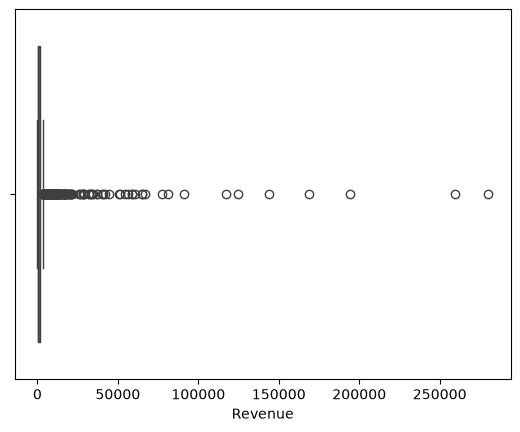

In [48]:
sns.boxplot(
    x=customer_revenue
)

plt.show()

Observation:

Revenue contains several high-value customer outliers. These customers represent a small fraction of the customer base but contribute disproportionately to total revenue. Rather than removing them, they will be retained because they are important for customer lifetime value estimation, revenue-at-risk analysis, and retention strategy development.

In [49]:
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"]
)

latest_date = clean_df["InvoiceDate"].max()

recency = (
    latest_date -
    clean_df.groupby("CustomerID")
            ["InvoiceDate"]
            .max()
).dt.days

In [50]:
recency.describe()

count    4338.000000
mean       91.536422
std       100.014169
min         0.000000
25%        17.000000
50%        50.000000
75%       141.000000
max       373.000000
Name: InvoiceDate, dtype: float64

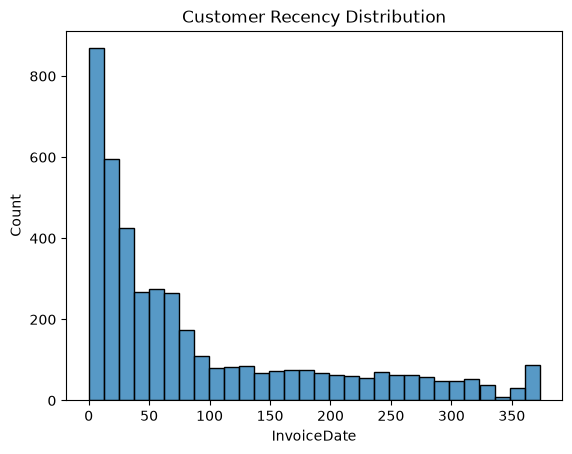

In [51]:
sns.histplot(
    recency,
    bins=30
)

plt.title("Customer Recency Distribution")
plt.show()

Observation:

Customer recency shows that a large proportion of customers have purchased recently, indicating an active customer base. However, a significant number of customers have not made a purchase for several months, with some customers inactive for nearly a year. These customers represent potential churn candidates and will be important for churn prediction and retention strategy development.

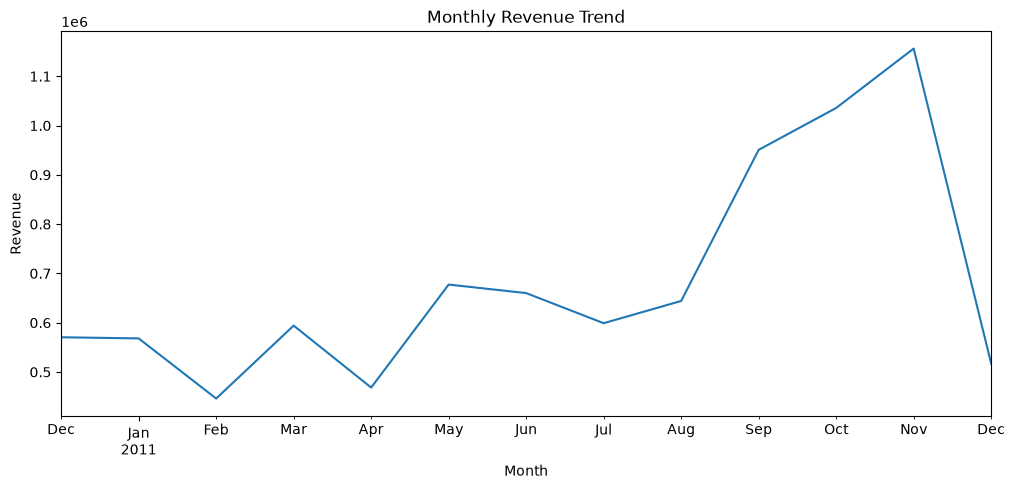

In [52]:
clean_df["Month"] = (
    clean_df["InvoiceDate"]
    .dt.to_period("M")
)

monthly_rev = (
    clean_df.groupby("Month")
    ["Revenue"]
    .sum()
)

plt.figure(figsize=(12,5))

monthly_rev.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

Observation:

Monthly revenue exhibits an upward trend throughout the year, with significant growth observed between September and November. Revenue peaks in November, indicating strong seasonal demand and increased customer activity. The sharp decline in the final month is likely due to incomplete data collection rather than a true decrease in business performance.

In [53]:
top_customers = (
    clean_df.groupby("CustomerID")
    ["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

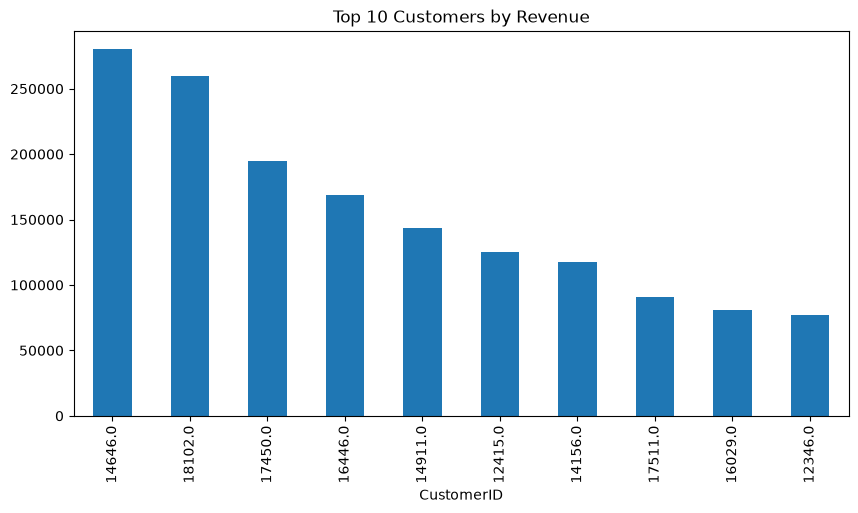

In [54]:
top_customers.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Revenue")
plt.show()

# Final EDA Conclusions

1. The dataset contains 4,338 customers and 18,532 completed transactions, generating approximately 8.89 million in revenue.

2. Customer purchase frequency is highly right-skewed. Most customers place only a few orders, while a small group purchases frequently.

3. Customer revenue distribution is highly concentrated, with a small number of customers generating a disproportionately large share of total revenue.

4. Revenue contains several high-value customer outliers. These customers are valuable business assets and should not be removed.

5. Recency analysis shows that many customers are active, while some customers have not purchased for several months and may be at risk of churn.

6. Monthly revenue exhibits strong growth toward the end of the year, suggesting seasonal purchasing behavior.

7. High-value customers contribute significantly to business revenue and should be targeted through personalized retention strategies.

8. The EDA confirms that Recency, Frequency, and Monetary Value (RFM) are strong candidate features for customer segmentation, churn prediction, customer lifetime value estimation, and revenue-at-risk analysis.